In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
def train_test_split(data, train_percentage, test_percentage):
    rows, col = data.shape
    shuffeled_data = data.sample(frac = 1)

    train_data = shuffeled_data.head(int((rows / 100) * train_percentage))
    test_data = shuffeled_data.tail(int((rows / 100) * test_percentage))

    return train_data, test_data
    

In [4]:
data = pd.read_csv(r"C:\Coding\Machine_Learning\Machine Learning Coding\LinearRegression\Practice Problems\Gradient Descent\Practice datasets\house_prices_dataset.csv")
data.head()

,area,price
0,2231.88,558852.17
1,2524.92,632260.29
2,1527.65,382994.25
3,1986.09,497607.86
4,2920.16,730870.84


In [5]:
train_data, test_data = train_test_split(data,80,20)

In [6]:
# Training model
rows, col = train_data.shape

X_Raw = train_data['area']
Y_Raw = train_data['price']

Y = (Y_Raw - np.mean(Y_Raw)) / np.std(Y_Raw)
X = (X_Raw - np.mean(X_Raw)) / np.std(X_Raw)

# Findind w and b value using closed form 
X_Mean = np.mean(X)
Y_Mean = np.mean(Y)

# Devitation
X_Dev = X - X_Mean
Y_Dev = Y - Y_Mean

# Product of Deviation
PROD_Dev = X_Dev * Y_Dev

# Sum of product of deviations
total = 0
for i in PROD_Dev:
    total = total + i
PROD_Dev_Sum = total

# Squared Deviation
Squared_Dev = np.sum(X_Dev**2)

# Slope
w = PROD_Dev_Sum/Squared_Dev

# Intercept
b = Y_Mean - (w * X_Mean)

print (f"{w}, {b}")

0.999999514939169, 9.769959439399731e-16


In [7]:
w = 1.5
b = 0.8
Y_pred = (w*X) + b
Y_pred.rename('PredictedPrice')

7    -1.188493
15    1.009493
21   -0.956982
27   -0.738686
6    -1.336226
        ...   
14    2.989829
42    2.941981
97    2.964457
43   -0.664308
71    1.455009
Name: PredictedPrice, Length: 80, dtype: float64

In [8]:
cost = (1/(2*rows)) * np.sum((Y_pred - Y)**2)
cost

np.float64(0.4450007275912457)

In [9]:
m = rows
# Build the grid of candidate w, b values (the "bowl" background)
w_range = np.linspace(-2,4,100)
b_range = np.linspace(-3,3,100)

W, B = np.meshgrid(w_range, b_range)

Z = np.zeros_like(W)

for row in range(W.shape[0]):
    for col in range(W.shape[1]):
        w_val = W[row, col]
        b_val = B[row, col]
        Y_pred_grid = (w_val * X) + b_val
        Z[row,col] = (1/(2*m)) * (np.sum((Y_pred_grid-Y)**2))
Z


array([[8.99999903, 8.82001742, 8.64370891, ..., 8.64371171, 8.82002028,
        9.00000194],
       [8.8200174 , 8.64003579, 8.46372728, ..., 8.46373007, 8.64003864,
        8.82002031],
       [8.64370886, 8.46372725, 8.28741874, ..., 8.28742153, 8.4637301 ,
        8.64371177],
       ...,
       [8.64370886, 8.46372725, 8.28741874, ..., 8.28742153, 8.4637301 ,
        8.64371177],
       [8.8200174 , 8.64003579, 8.46372728, ..., 8.46373007, 8.64003864,
        8.82002031],
       [8.99999903, 8.82001742, 8.64370891, ..., 8.64371171, 8.82002028,
        9.00000194]], shape=(100, 100))

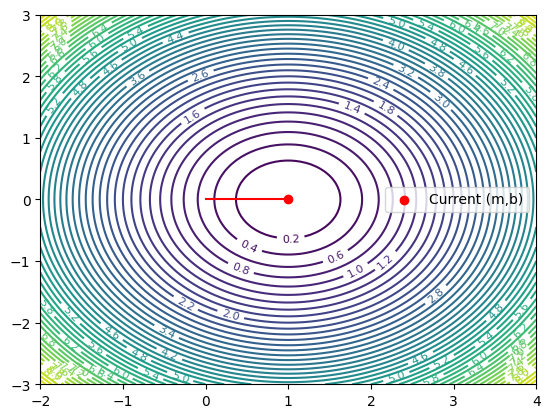

0.9975945068144336, 9.98881099362192e-16


In [10]:
iterations = 600
w = 0
b = 0
w_history = [w]
b_history = [b]
cost_history = []
ALPHA = 0.01
from IPython import display  # <-- Added this import

for i in range(iterations):
    Y_Pred = (w * X) + b

    w = w - (ALPHA * ((1/m) * np.sum((Y_Pred-Y)*X)))
    b = b - (ALPHA * ((1/m) * np.sum(Y_Pred-Y)))

    w_history.append(w)
    b_history.append(b)

    cost = (1/m) * (np.sum((Y_Pred-Y)**2))
    cost_history.append(cost)

    if i % 10 == 0 or i == iterations - 1:
        display.clear_output(wait=True)  # <-- Clears the previous plot smoothly
        plt.figure()                     # <-- Ensures a clean figure canvas
        contours = plt.contour(W,B,Z,levels = 50, cmap = 'viridis')
        plt.plot(w_history,b_history, color = 'red')
        plt.scatter([w], [b], color = 'red', label = 'Current (m,b)')
        plt.clabel(contours, inline=True, fontsize=8)
        # plt.set_title("Cost surface J(m, b)")
        # plt.set_xlabel("m")
        # plt.set_ylabel("b")
        plt.legend()

        
        plt.show()                    # <-- Replaced plt.pause() with plt.show()
print (f"{w}, {b}")

Text(0.5, 0.92, 'Cost Surface J(w, b) with Gradient Descent Path')

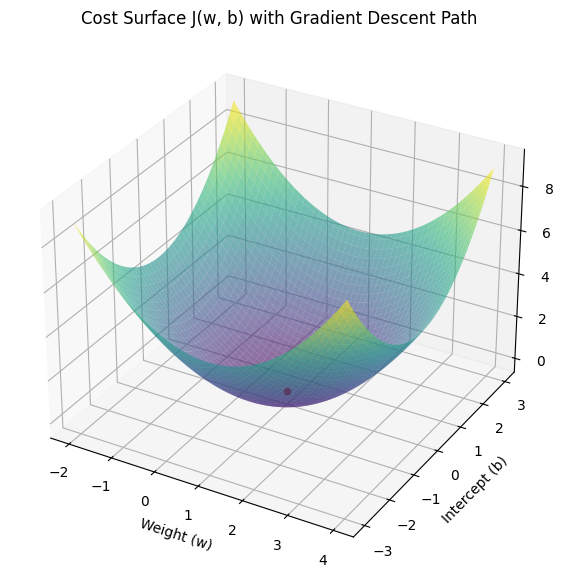

In [11]:
# Set up 3D figure
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Draw the bowl surface once (semi-transparent so the descent path is visible through it)
ax.plot_surface(W, B, Z, cmap='viridis', alpha=0.6, edgecolor='none')
ax.scatter(w,b,color = 'red')
ax.set_xlabel('Weight (w)')
ax.set_ylabel('Intercept (b)')
ax.set_zlabel('Cost (MSE)')
ax.set_title('Cost Surface J(w, b) with Gradient Descent Path')

In [12]:
w = 0.9999563504534911
b = 0
rows, col = test_data.shape
X_Test = test_data['area']
Y_Test = test_data['price']

Y_Test = (Y_Test - np.mean(Y_Test)) / np.std(Y_Test)
X_Test = (X_Test - np.mean(X_Test)) / np.std(X_Test)

Y_Test_Pred = (w * X_Test) + b

new_cost = (1/(2*rows)) * np.sum((Y_Test_Pred - Y_Test)**2)
new_cost

np.float64(3.5428386897094717e-07)

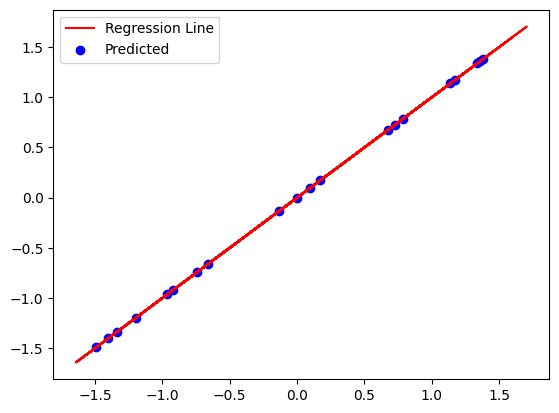

In [17]:
plt.plot(X,(X * w) + b, color = 'red',label = 'Regression Line')
plt.scatter(X_Test,Y_Test_Pred, label = 'Predicted', color = 'blue')
plt.legend()
plt.show()


In [22]:
MSE = (1/(2*rows)) * np.sum((Y_Test_Pred - Y_Test)**2)
MSE

np.float64(3.5428386897094717e-07)

In [23]:
RMSE = np.sqrt(MSE)
RMSE

np.float64(0.0005952174971982487)

In [26]:
R2 = 1 - (np.sum((Y_Test-Y_Test_Pred)**2)/np.sum((Y_Test-np.mean(Y_Test))**2))
R2

np.float64(0.9999992914322621)

In [27]:
new_area = 3000  # your own raw value
new_area_scaled = (new_area - np.mean(X_Raw)) / np.std(X_Raw)

Y_pred_scaled = w * new_area_scaled + b

predicted_price = (Y_pred_scaled * np.std(Y_Raw)) + np.mean(Y_Raw)

predicted_price

np.float64(750997.5587513112)